# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE Batch 1 (2026–2027)

### Project Objective

The objective of this project is to analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

The analysis focuses on:

- Agricultural performance across seasons
- Environmental conditions
- Resource usage
- Crop performance
- Irrigation methods
- Economic outcomes
- Relationships between variables
- Statistical differences between seasons
- Data-driven recommendations

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

Therefore, this project analyzes the given agricultural dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 2. Objectives

The main objectives of this project are:

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal conditions and agricultural outcomes.
6. Compare relevant groups within different seasons.
7. Identify significant differences or unusual patterns.
8. Apply appropriate statistical and visualization techniques.
9. Interpret findings based on evidence from the dataset.
10. Develop meaningful conclusions and data-driven recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Dataset Shape: (4000, 28)

Column Names:
1 : Farm_ID
2 : State
3 : District
4 : Crop
5 : Season
6 : Farm_Area_Hectares
7 : Rainfall_mm
8 : Avg_Temperature_C
9 : Humidity_pct
10 : Sunlight_Hours_Day
11 : Soil_pH
12 : Soil_Moisture_pct
13 : Nitrogen_kg_ha
14 : Phosphorus_kg_ha
15 : Potassium_kg_ha
16 : Irrigation_Method
17 : Fertilizer_kg_ha
18 : Pesticide_Litre_ha
19 : Seed_Quality_Score
20 : Yield_Tonnes_Ha
21 : Production_Tonnes
22 : Market_Price_INR_Tonne
23 : Total_Cost_INR
24 : Revenue_INR
25 : Profit_INR
26 : Water_Used_m3
27 : Water_Efficiency_t_per_1000m3
28 : Disease_Pest_Risk_pct


In [5]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [6]:
missing = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing)

Missing Values in Each Column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [7]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 120


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].describe()

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
count,3952.000000,3960.000000,3968.000000
mean,601.152657,26.508232,5.270595
std,288.925025,6.712484,13.361398
min,80.000000,8.000000,0.300000
25%,370.200000,21.700000,1.050000
50%,582.000000,26.400000,1.740000
75%,834.950000,31.300000,2.840000
max,1395.200000,47.000000,101.440000


In [10]:
df[df[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].isnull().any(axis=1)]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
28,SF10029,Tamil Nadu,Rajkot,Maize,Rabi,12.94,443.1,23.0,45.7,6.3,...,0.97,3.01,38.95,20272,1176978,789594,-387384,8230,4.733,32.1
43,SF10044,Tamil Nadu,Erode,Wheat,Rabi,7.56,460.1,24.0,58.7,6.7,...,0.69,2.60,19.66,24887,550176,489278,-60898,4545,4.326,44.7
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
121,SF10122,Maharashtra,Erode,Cotton,Kharif,3.26,896.1,34.8,69.5,7.2,...,0.98,0.30,0.98,57631,193353,56478,-136875,2439,0.402,51.3
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3937,SF13938,Madhya Pradesh,Erode,Wheat,Kharif,2.44,NaN,22.6,69.9,8.3,...,0.79,2.98,7.27,23624,133843,171746,37903,1177,6.177,49.9
3946,SF13947,Madhya Pradesh,Ludhiana,Chilli,Rabi,5.18,572.1,21.6,69.4,9.1,...,0.84,NaN,2.75,107687,335676,296139,-39537,3646,0.754,42.9
3954,SF13955,Maharashtra,Erode,Maize,Kharif,8.25,708.1,31.9,75.4,7.7,...,0.72,1.28,10.56,21456,522222,226575,-295647,4824,2.189,52.7
3972,SF13973,Andhra Pradesh,Raichur,Maize,Kharif,14.22,NaN,25.6,67.9,7.9,...,0.74,3.49,49.63,18976,1005620,941779,-63841,9700,5.116,52.2


In [11]:
print("Median Rainfall:", df["Rainfall_mm"].median())
print("Median Soil Moisture:", df["Soil_Moisture_pct"].median())
print("Median Yield:", df["Yield_Tonnes_Ha"].median())

Median Rainfall: 582.0
Median Soil Moisture: 26.4
Median Yield: 1.74


In [12]:
df_clean = df.copy()

df_clean["Rainfall_mm"] = df_clean["Rainfall_mm"].fillna(df_clean["Rainfall_mm"].median())

df_clean["Soil_Moisture_pct"] = df_clean["Soil_Moisture_pct"].fillna(df_clean["Soil_Moisture_pct"].median())

df_clean["Yield_Tonnes_Ha"] = df_clean["Yield_Tonnes_Ha"].fillna(df_clean["Yield_Tonnes_Ha"].median())

In [13]:
df_clean.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [14]:
print("Total missing values after cleaning:", df_clean.isnull().sum().sum())

Total missing values after cleaning: 0


In [15]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [16]:
print("Number of Rows:", df_clean.shape[0])
print("Number of Columns:", df_clean.shape[1])

Number of Rows: 4000
Number of Columns: 28


In [17]:
df_clean.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [18]:
df_clean.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [19]:
print("Seasons:")
print(df_clean["Season"].value_counts())

print("\nCrops:")
print(df_clean["Crop"].value_counts())

print("\nIrrigation Methods:")
print(df_clean["Irrigation_Method"].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [20]:
print("Number of States:", df_clean["State"].nunique())

print("\nStates:")
print(df_clean["State"].unique())

Number of States: 8

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


In [21]:
print("Number of Districts:", df_clean["District"].nunique())

Number of Districts: 10


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the structure and characteristics of the cleaned agricultural dataset.

The analysis examines:

- Distribution of agricultural seasons
- Crop distribution
- Irrigation methods
- Geographic distribution
- Agricultural yield
- Production
- Revenue and profit
- Water usage and efficiency
- Environmental conditions
- Relationships between agricultural variables

In [22]:
print("SEASONS")
print(df_clean["Season"].value_counts())

print("\nCROPS")
print(df_clean["Crop"].value_counts())

print("\nIRRIGATION METHODS")
print(df_clean["Irrigation_Method"].value_counts())



SEASONS
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

CROPS
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

IRRIGATION METHODS
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [23]:
# Statistical Summary of Numerical Columns

df_clean.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [24]:
# Average Yield by Season

season_yield = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean()

print("Average Yield by Season:")
print(season_yield)

Average Yield by Season:
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


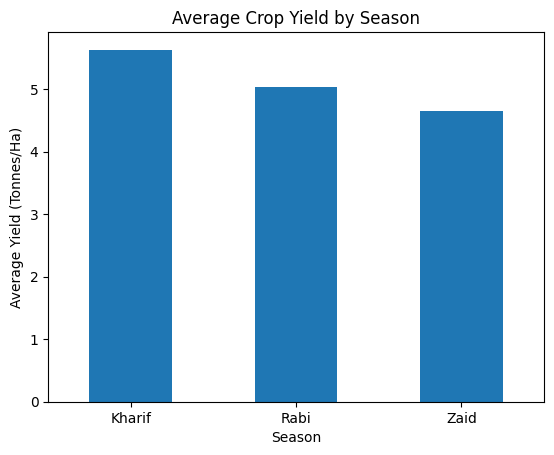

In [25]:
# Bar Chart - Average Yield by Season

import matplotlib.pyplot as plt

season_yield.plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

In [26]:
# Average Yield by Crop

crop_yield = df_clean.groupby("Crop")["Yield_Tonnes_Ha"].mean()

print("Average Yield by Crop:")
print(crop_yield.sort_values(ascending=False))

Average Yield by Crop:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


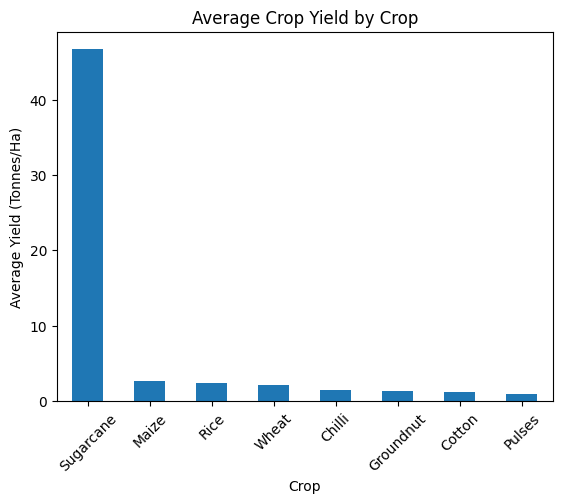

In [27]:
# Bar Chart - Average Yield by Crop

crop_yield.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Crop Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [28]:
# Average Profit by Crop

crop_profit = df_clean.groupby("Crop")["Profit_INR"].mean()

print("Average Profit by Crop:")
print(crop_profit.sort_values(ascending=False))

Average Profit by Crop:
Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


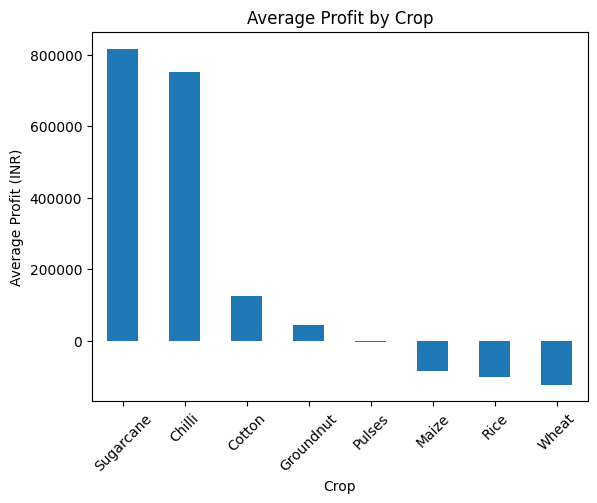

In [29]:
crop_profit.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

In [30]:
# Water Usage and Efficiency by Irrigation Method

water_analysis = df_clean.groupby("Irrigation_Method")[
    ["Water_Used_m3", "Water_Efficiency_t_per_1000m3"]
].mean()

print("Average Water Usage and Efficiency by Irrigation Method:")
print(water_analysis)

Average Water Usage and Efficiency by Irrigation Method:
                   Water_Used_m3  Water_Efficiency_t_per_1000m3
Irrigation_Method                                              
Drip                 5918.747541                       6.267129
Flood                8026.472519                       3.438853
Rainfed              3549.554275                       7.563784
Sprinkler            6208.258856                       4.669805


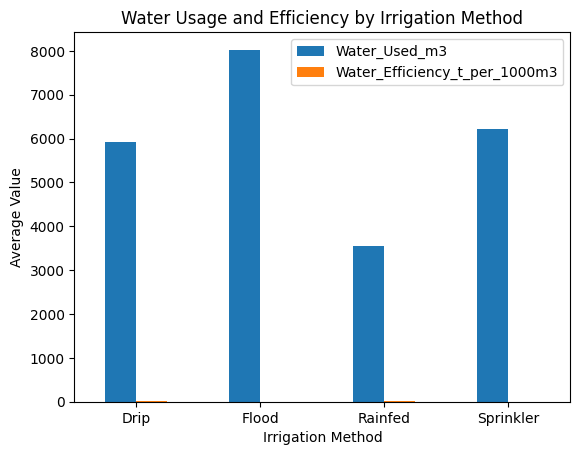

In [31]:
water_analysis.plot(kind="bar")

plt.title("Water Usage and Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

In [32]:
season_production = df_clean.groupby("Season")["Production_Tonnes"].mean()

print("Average Production by Season:")
print(season_production)

Average Production by Season:
Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


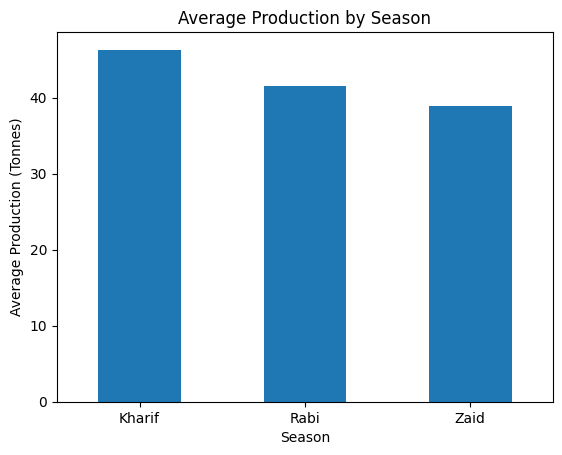

In [33]:
season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=0)
plt.show()

In [34]:
season_revenue = df_clean.groupby("Season")["Revenue_INR"].mean()

print("Average Revenue by Season:")
print(season_revenue)

Average Revenue by Season:
Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


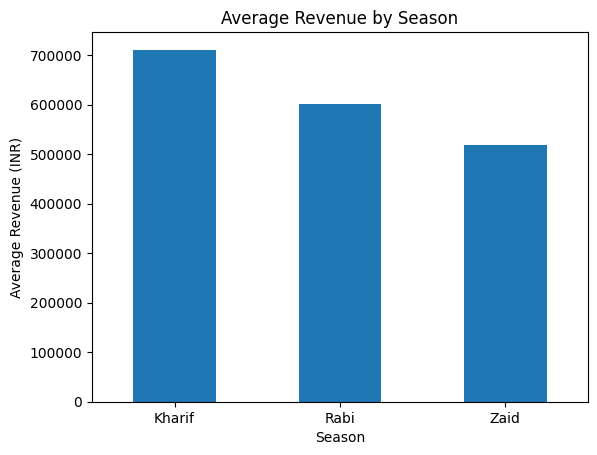

In [35]:
season_revenue.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=0)
plt.show()

In [36]:
season_profit = df_clean.groupby("Season")["Profit_INR"].mean()

print("Average Profit by Season:")
print(season_profit)

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


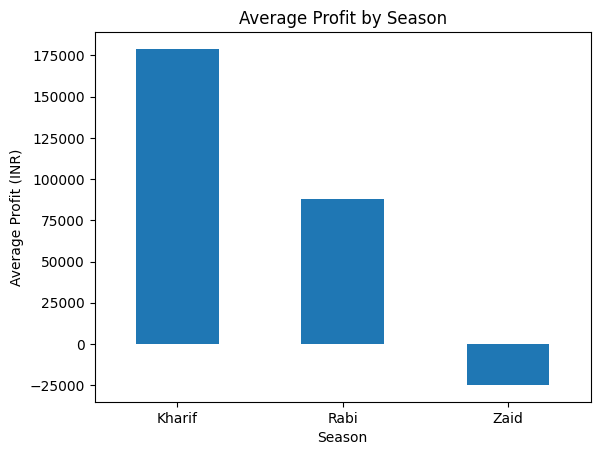

In [37]:
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

In [38]:
season_environment = df_clean.groupby("Season")[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct"
    ]
].mean()

print("Average Environmental Conditions by Season:")
print(season_environment)

Average Environmental Conditions by Season:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif   849.199663          28.454019     71.812591            6.793367   
Rabi     437.615366          23.489183     57.893178            7.589797   
Zaid     304.654714          31.042088     52.012121            8.178788   

         Soil_pH  Soil_Moisture_pct  
Season                               
Kharif  6.727993          31.149859  
Rabi    6.673749          24.069392  
Zaid    6.694865          19.279630  


In [39]:
season_water = df_clean.groupby("Season")["Water_Used_m3"].mean()

print("Average Water Usage by Season:")
print(season_water)

Average Water Usage by Season:
Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


In [40]:
season_fertilizer = df_clean.groupby("Season")["Fertilizer_kg_ha"].mean()

print("Average Fertilizer Usage by Season:")
print(season_fertilizer)

Average Fertilizer Usage by Season:
Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


In [41]:
season_pesticide = df_clean.groupby("Season")["Pesticide_Litre_ha"].mean()

print("Average Pesticide Usage by Season:")
print(season_pesticide)

Average Pesticide Usage by Season:
Season
Kharif    5.079747
Rabi      5.024690
Zaid      5.171212
Name: Pesticide_Litre_ha, dtype: float64


In [42]:
season_water_efficiency = df_clean.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

print("Average Water Efficiency by Season:")
print(season_water_efficiency)

Average Water Efficiency by Season:
Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


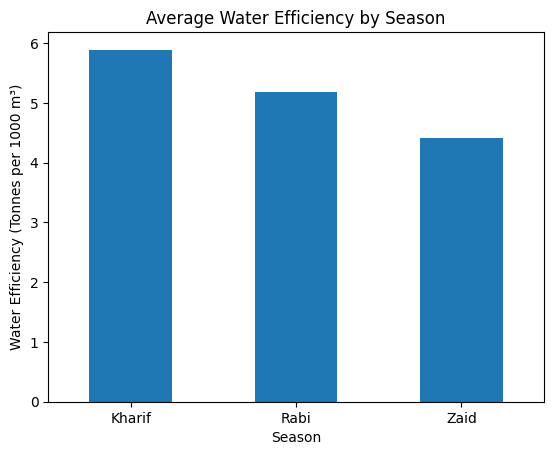

In [43]:
season_water_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=0)
plt.show()

In [44]:
irrigation_season = pd.crosstab(
    df_clean["Season"],
    df_clean["Irrigation_Method"]
)

print("Irrigation Method Usage Across Seasons:")
print(irrigation_season)

Irrigation Method Usage Across Seasons:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120


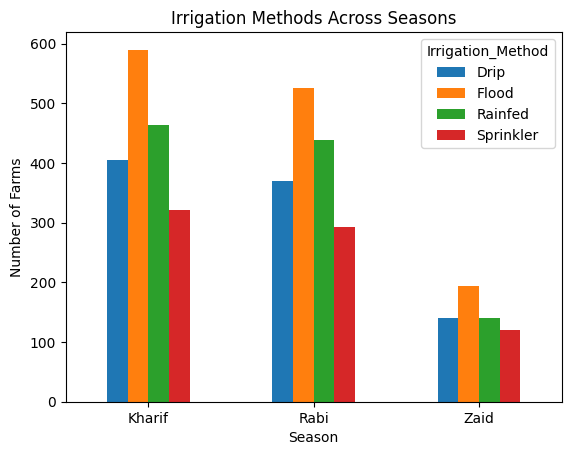

In [45]:
irrigation_season.plot(kind="bar")

plt.title("Irrigation Methods Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.show()

In [46]:
season_crop = pd.crosstab(
    df_clean["Season"],
    df_clean["Crop"]
)

print("Crop Distribution Across Seasons:")
print(season_crop)

Crop Distribution Across Seasons:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85


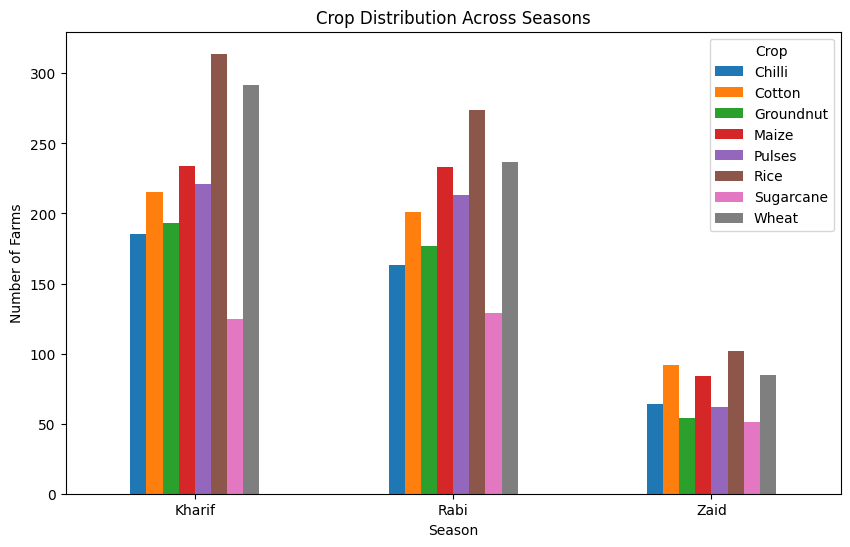

In [47]:
season_crop.plot(kind="bar", figsize=(10, 6))

plt.title("Crop Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.show()

In [48]:
season_crop_yield = df_clean.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean()

print("Average Yield by Season and Crop:")
print(season_crop_yield)


Average Yield by Season and Crop:
Season  Crop     
Kharif  Chilli        1.731459
        Cotton        1.374512
        Groundnut     1.484974
        Maize         2.966410
        Pulses        1.036063
        Rice          2.698376
        Sugarcane    53.459120
        Wheat         2.253664
Rabi    Chilli        1.465031
        Cotton        1.198358
        Groundnut     1.233164
        Maize         2.603648
        Pulses        0.875962
        Rice          2.322847
        Sugarcane    43.286124
        Wheat         2.057468
Zaid    Chilli        1.195312
        Cotton        0.960217
        Groundnut     1.037778
        Maize         2.290952
        Pulses        0.669677
        Rice          1.900490
        Sugarcane    38.423922
        Wheat         1.748588
Name: Yield_Tonnes_Ha, dtype: float64


season_crop_yield_table = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print(season_crop_yield_table)


In [49]:
state_season_yield = df_clean.groupby(
    ["State", "Season"]
)["Yield_Tonnes_Ha"].mean()

print("Average Yield by State and Season:")
print(state_season_yield)

Average Yield by State and Season:
State           Season
Andhra Pradesh  Kharif    5.676958
                Rabi      3.470931
                Zaid      4.448000
Gujarat         Kharif    6.338416
                Rabi      5.441700
                Zaid      4.066716
Karnataka       Kharif    6.455024
                Rabi      4.567864
                Zaid      6.623243
Madhya Pradesh  Kharif    5.985265
                Rabi      3.760385
                Zaid      5.478889
Maharashtra     Kharif    5.430315
                Rabi      5.501927
                Zaid      2.277778
Punjab          Kharif    4.100633
                Rabi      8.609355
                Zaid      5.909610
Tamil Nadu      Kharif    5.520534
                Rabi      4.501394
                Zaid      4.097746
Telangana       Kharif    5.552436
                Rabi      4.784569
                Zaid      4.248471
Name: Yield_Tonnes_Ha, dtype: float64


In [50]:
state_season_table = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

print(state_season_table)

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  5.676958  3.470931  4.448000
Gujarat         6.338416  5.441700  4.066716
Karnataka       6.455024  4.567864  6.623243
Madhya Pradesh  5.985265  3.760385  5.478889
Maharashtra     5.430315  5.501927  2.277778
Punjab          4.100633  8.609355  5.909610
Tamil Nadu      5.520534  4.501394  4.097746
Telangana       5.552436  4.784569  4.248471


In [51]:
correlation = df_clean.select_dtypes(
    include="number"
).corr()

print(correlation)

                               Farm_Area_Hectares  Rainfall_mm  \
Farm_Area_Hectares                       1.000000     0.007256   
Rainfall_mm                              0.007256     1.000000   
Avg_Temperature_C                        0.036870     0.198492   
Humidity_pct                             0.000471     0.521069   
Sunlight_Hours_Day                       0.001821    -0.362779   
Soil_pH                                  0.009857     0.016657   
Soil_Moisture_pct                        0.004033     0.508941   
Nitrogen_kg_ha                           0.013658     0.007460   
Phosphorus_kg_ha                        -0.006625     0.020940   
Potassium_kg_ha                          0.000195     0.031373   
Fertilizer_kg_ha                         0.014975     0.024602   
Pesticide_Litre_ha                      -0.005207     0.004058   
Seed_Quality_Score                       0.015236    -0.018581   
Yield_Tonnes_Ha                          0.030203     0.030951   
Production

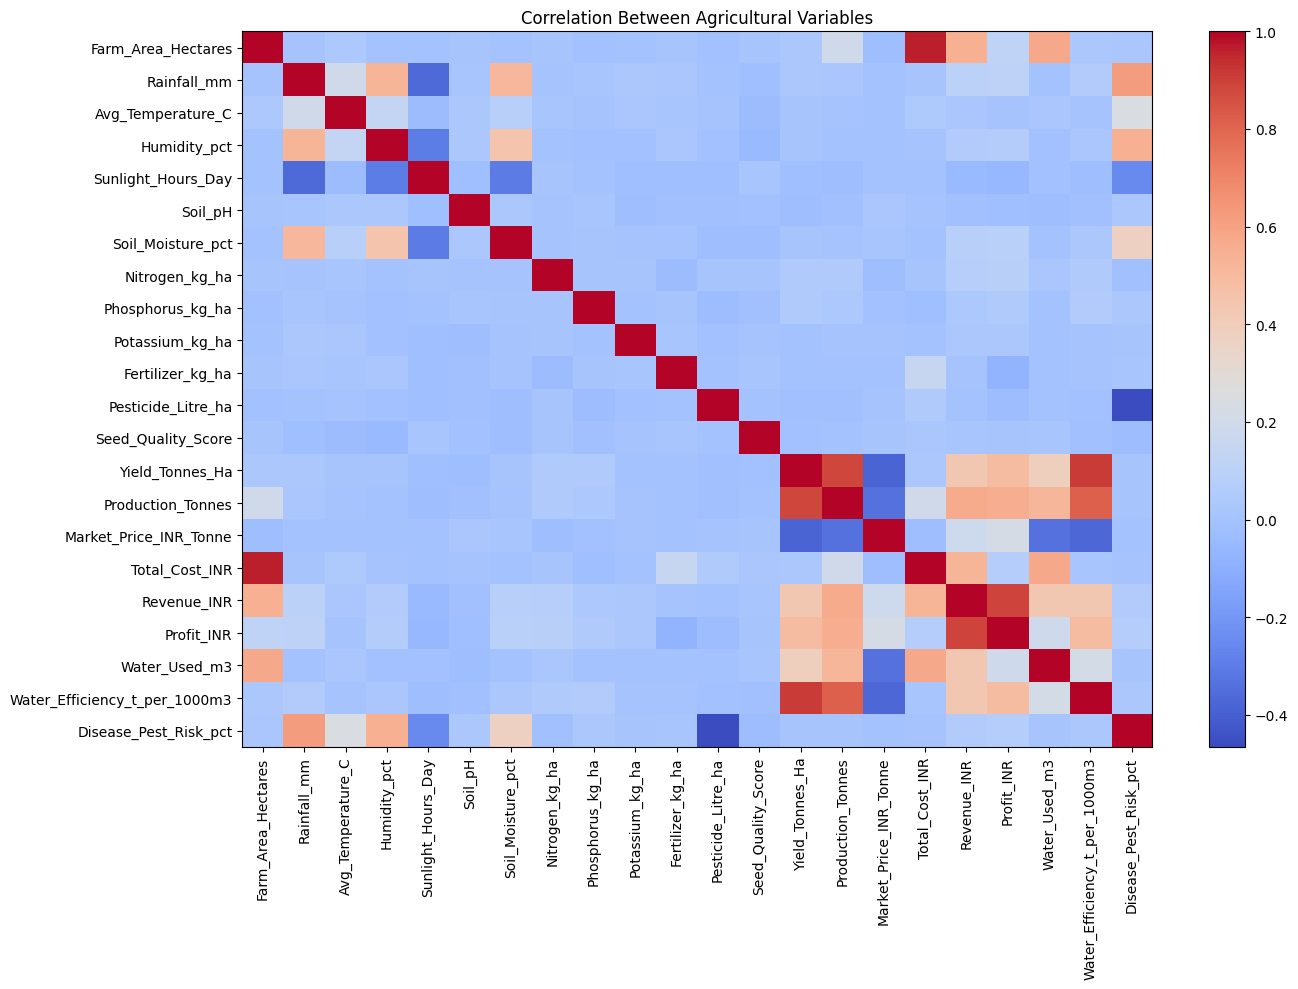

In [52]:
plt.figure(figsize=(14, 10))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between Agricultural Variables")

plt.tight_layout()
plt.show()

In [53]:
yield_correlation = correlation["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

print("Correlation with Yield:")
print(yield_correlation)

Correlation with Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


In [54]:
profit_correlation = correlation["Profit_INR"].sort_values(
    ascending=False
)

print("Correlation with Profit:")
print(profit_correlation)

Correlation with Profit:
Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


## Seasonal Environmental Conditions and Yield

This analysis investigates whether environmental conditions such as rainfall, temperature, humidity, sunlight and soil moisture have different relationships with crop yield across seasons.

In [55]:
environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

seasonal_environment_yield_corr = {}

for season in df_clean["Season"].unique():
    seasonal_environment_yield_corr[season] = (
        df_clean[df_clean["Season"] == season][
            environmental_columns + ["Yield_Tonnes_Ha"]
        ]
        .corr()["Yield_Tonnes_Ha"]
        .drop("Yield_Tonnes_Ha")
    )

seasonal_environment_yield_corr = pd.DataFrame(
    seasonal_environment_yield_corr
)

print("Environmental Factors vs Yield by Season:")
print(seasonal_environment_yield_corr)

Environmental Factors vs Yield by Season:
                      Kharif      Rabi      Zaid
Rainfall_mm        -0.015495  0.044218  0.052289
Avg_Temperature_C  -0.011471  0.054888 -0.043654
Humidity_pct       -0.016074  0.018869 -0.061328
Sunlight_Hours_Day -0.021214  0.010345  0.022538
Soil_Moisture_pct   0.000641 -0.016927 -0.030688


## Statistical Test for Yield Differences Across Seasons

A statistical test is used to determine whether the observed differences in average yield across seasons are statistically significant.

## Statistical Test for Yield Differences Across Seasons

The Kruskal-Wallis test is used to determine whether crop yield differs significantly across Kharif, Rabi and Zaid seasons.

The null hypothesis states that the yield distributions are similar across the three seasons.

A significance level of 0.05 is used.

In [56]:
# Statistical Test for Yield Differences Across Seasons

kharif_yield = df_clean[df_clean["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = df_clean[df_clean["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = df_clean[df_clean["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

# Combine the three groups
all_yield = pd.concat([
    kharif_yield,
    rabi_yield,
    zaid_yield
])

# Assign ranks to all observations
ranks = all_yield.rank(method="average")

# Get ranks for each season
R1 = ranks.iloc[:len(kharif_yield)].sum()
R2 = ranks.iloc[
    len(kharif_yield):
    len(kharif_yield) + len(rabi_yield)
].sum()
R3 = ranks.iloc[
    len(kharif_yield) + len(rabi_yield):
].sum()

n1 = len(kharif_yield)
n2 = len(rabi_yield)
n3 = len(zaid_yield)

N = n1 + n2 + n3

# Kruskal-Wallis H statistic
H = (
    (12 / (N * (N + 1))) *
    (
        (R1 ** 2) / n1 +
        (R2 ** 2) / n2 +
        (R3 ** 2) / n3
    )
    - 3 * (N + 1)
)

# Tie correction
tie_counts = all_yield.value_counts()
tie_sum = ((tie_counts ** 3) - tie_counts).sum()

tie_correction = 1 - tie_sum / (N ** 3 - N)

H_corrected = H / tie_correction

# For 3 groups, degrees of freedom = 2
# Chi-square survival probability for df=2
p_value = np.exp(-H_corrected / 2)

print("Kruskal-Wallis Test")
print("--------------------")
print("Test Statistic (H):", round(H_corrected, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("\nResult: Yield differences between seasons are statistically significant.")
else:
    print("\nResult: Yield differences between seasons are not statistically significant.")

Kruskal-Wallis Test
--------------------
Test Statistic (H): 68.7131
P-value: 0.0

Result: Yield differences between seasons are statistically significant.


### Statistical Finding

The p-value is less than 0.05. Therefore, the null hypothesis is rejected.

This indicates that there is a statistically significant difference in crop yield across Kharif, Rabi and Zaid seasons in the supplied dataset.

In [57]:
# Average Yield by Irrigation Method

irrigation_yield = (
    df_clean.groupby("Irrigation_Method")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Irrigation Method:")
print(irrigation_yield)

Average Yield by Irrigation Method:
Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64


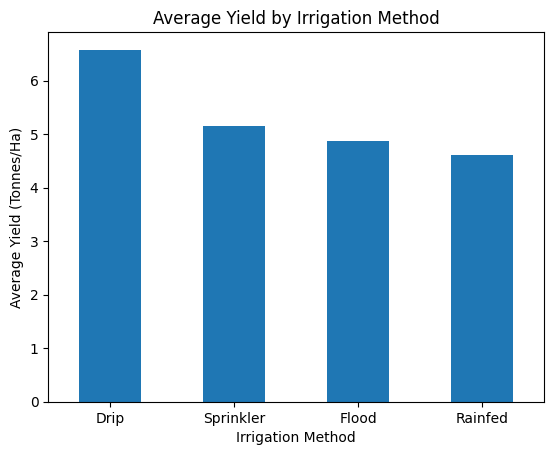

In [58]:
irrigation_yield.plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.show()

In [59]:
# Average Yield by Irrigation Method and Season

irrigation_season_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
)

print("Average Yield by Irrigation Method and Season:")
print(irrigation_season_yield)

Average Yield by Irrigation Method and Season:
Season               Kharif      Rabi      Zaid
Irrigation_Method                              
Drip               7.256296  6.111676  5.848143
Flood              4.977915  5.060589  3.984381
Rainfed            5.703996  3.929110  3.063786
Sprinkler          4.662243  5.307235  6.135833


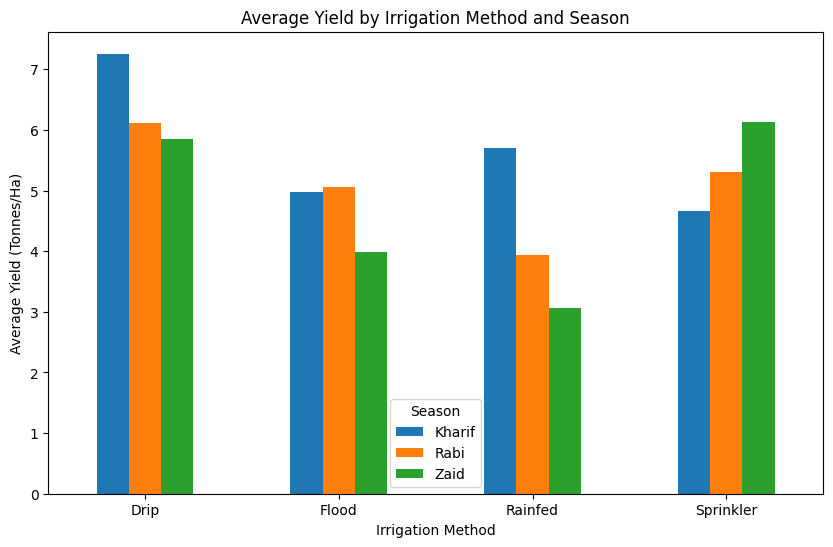

In [60]:
irrigation_season_yield.plot(kind="bar", figsize=(10, 6))

plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.show()

## Data-Driven Recommendations

Based on the analysis, the following recommendations can be made:

1. Farmers should consider seasonal conditions when planning crop production because yield differs significantly across Kharif, Rabi and Zaid seasons.

2. Irrigation methods should be selected according to the season and expected crop performance rather than using the same method throughout the year.

3. Water-efficient irrigation methods should be preferred where they provide good yield while reducing water consumption.

4. Crop selection should consider both yield and economic performance. Crops with consistently higher yield and profitability can be prioritized where environmental and market conditions are suitable.

5. Environmental conditions such as rainfall, temperature, humidity, sunlight and soil moisture should be monitored to support better seasonal farming decisions.

6. Fertilizer and pesticide usage should be managed carefully according to crop and seasonal requirements to avoid unnecessary resource usage.

7. Revenue and production should be monitored together because revenue showed a strong positive relationship with profit.

8. Data-based seasonal planning can help improve agricultural productivity, resource efficiency and profitability.

## Conclusion

This project analyzed seasonal agricultural performance using information related to crops, seasons, irrigation methods, environmental conditions, resource usage, production and economic outcomes.

The analysis showed that Kharif had the highest average yield among the three seasons, while Zaid had the lowest average yield. Crop-level analysis showed that Sugarcane had a substantially higher average yield than the other crops in the dataset.

The analysis also showed differences in irrigation performance across seasons. Environmental variables were examined to understand their relationship with yield, while correlation analysis was used to identify relationships between agricultural and economic variables.

The Kruskal-Wallis statistical test indicated that the differences in yield across Kharif, Rabi and Zaid were statistically significant (H = 68.7131, p < 0.05). Therefore, seasonal variation is an important factor when analyzing agricultural yield in this dataset.

Overall, the findings demonstrate that seasonal planning, appropriate crop selection, efficient irrigation and monitoring of environmental and resource conditions can support better agricultural decision-making.

## Economic Performance by Crop and Season

In [61]:
# Average Profit by Crop and Season

crop_season_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print("Average Profit by Crop and Season:")
print(crop_season_profit)

Average Profit by Crop and Season:
Season           Kharif           Rabi           Zaid
Crop                                                 
Chilli     9.543804e+05  638572.496933  448659.093750
Cotton     2.169995e+05  107343.587065  -53925.336957
Groundnut  1.082654e+05   10416.542373  -68872.500000
Maize     -3.933267e+04  -89133.403433 -194049.166667
Pulses     4.333890e+04  -14309.136150 -139227.806452
Rice      -6.490340e+04  -98427.868613 -227239.343137
Sugarcane  1.000791e+06  731612.860465  583635.803922
Wheat     -1.058719e+05 -119954.565401 -193208.952941


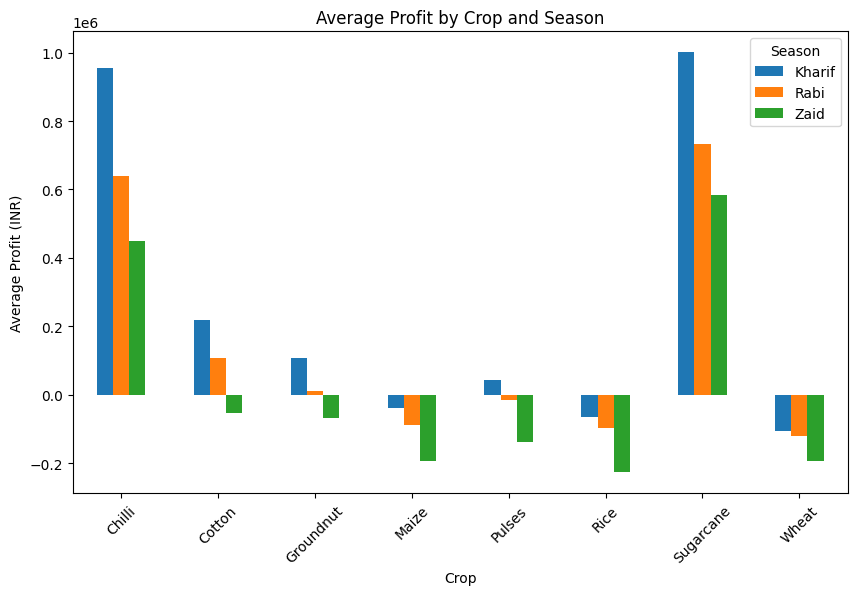

In [62]:
crop_season_profit.plot(kind="bar", figsize=(10, 6))

plt.title("Average Profit by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

## Production by Crop and Season

In [63]:
crop_season_production = df_clean.pivot_table(
    values="Production_Tonnes",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print("Average Production by Crop and Season:")
print(crop_season_production)

Average Production by Crop and Season:
Season         Kharif        Rabi        Zaid
Crop                                         
Chilli      14.463459   10.965951    9.977500
Cotton      10.408558    9.440995    6.930652
Groundnut   10.490259    9.061582    8.621296
Maize       23.348462   21.591330   17.941429
Pulses       8.286697    7.198498    4.942903
Rice        22.449650   17.223504   15.105098
Sugarcane  446.074960  365.263256  329.561569
Wheat       18.308048   16.065949   14.055529


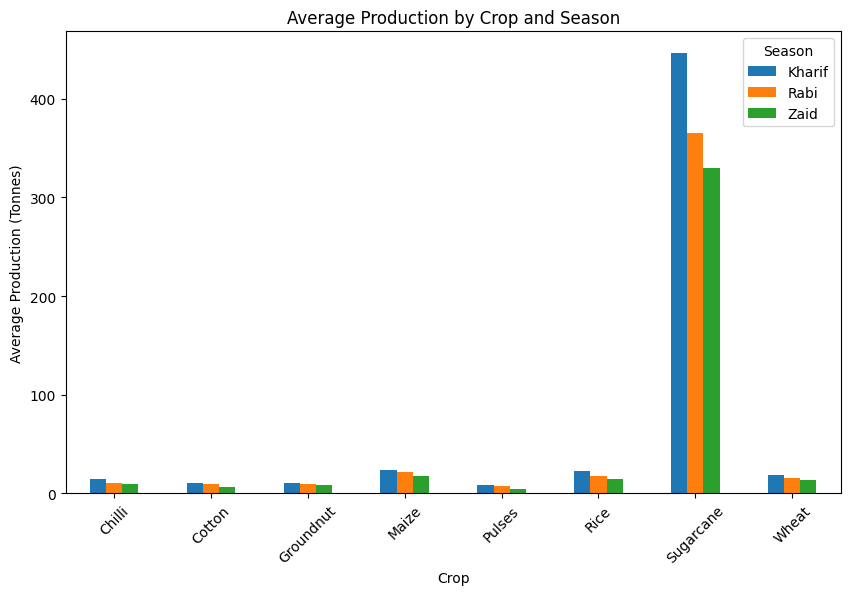

In [64]:
crop_season_production.plot(kind="bar", figsize=(10, 6))

plt.title("Average Production by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=45)

plt.show()

## Best Performing Categories

In [65]:
print("Best Performing Season:")
print(season_yield.idxmax(), "with average yield of",
      round(season_yield.max(), 2), "tonnes/ha")

print("\nBest Performing Crop:")
print(crop_yield.idxmax(), "with average yield of",
      round(crop_yield.max(), 2), "tonnes/ha")

print("\nMost Profitable Crop:")
print(crop_profit.idxmax(), "with average profit of",
      round(crop_profit.max(), 2), "INR")

print("\nBest Irrigation Method by Average Yield:")
print(irrigation_yield.idxmax(), "with average yield of",
      round(irrigation_yield.max(), 2), "tonnes/ha")

print("\nMost Water-Efficient Irrigation Method:")
print(water_analysis["Water_Efficiency_t_per_1000m3"].idxmax(),
      "with efficiency of",
      round(water_analysis["Water_Efficiency_t_per_1000m3"].max(), 2))

Best Performing Season:
Kharif with average yield of 5.63 tonnes/ha

Best Performing Crop:
Sugarcane with average yield of 46.64 tonnes/ha

Most Profitable Crop:
Sugarcane with average profit of 817187.99 INR

Best Irrigation Method by Average Yield:
Drip with average yield of 6.58 tonnes/ha

Most Water-Efficient Irrigation Method:
Rainfed with efficiency of 7.56


## Final Conclusions

Based on the analysis, agricultural performance varies across Kharif, Rabi and Zaid seasons.

- Kharif shows the strongest overall performance in the dataset.
- Zaid shows the weakest overall economic outcome.
- Environmental conditions vary across seasons and may be associated with differences in agricultural performance.
- Sugarcane has exceptionally high yield compared with the other crops.
- Drip irrigation shows the highest average yield among the irrigation methods analyzed.
- Rainfed farming shows the highest average water-efficiency measure, but it does not produce the highest profit.
- The Kruskal-Wallis test indicates that yield differences across Kharif, Rabi and Zaid are statistically significant.
- Correlation results show relationships between agricultural and economic variables, but correlation does not establish causation.

## Evidence-Based Recommendations

- Use season-specific agricultural planning rather than applying the same strategy to every season.
- Investigate the factors responsible for the stronger performance observed during Kharif.
- Investigate the negative aggregate profitability observed during Zaid, particularly costs, crop selection and resource usage.
- Consider drip irrigation when the objective is to improve yield and profitability, while also considering crop type and water availability.
- Analyze crop-level performance before making seasonal decisions because crop composition can influence seasonal averages.
- Monitor disease and pest risk because it shows noticeable seasonal variation.
- Improve water management by considering both water efficiency and profitability when selecting irrigation methods.
- Use additional multi-year and location-specific data in future analysis to validate whether these patterns remain consistent.

## Limitations

- The analysis is based on the supplied dataset and does not contain multiple years of observations.
- Some missing values were handled during data preparation, which may influence certain results.
- Some variables are mathematically related, so correlations between them should be interpreted carefully.
- The analysis is observational and therefore does not prove causal relationships.
- Seasonal averages may be influenced by differences in crop composition.
- The project focuses on descriptive and diagnostic analysis rather than predictive modelling.

## Problem Statement Coverage

| Requirement | Status |
|---|---|
| Explore and understand the dataset | Completed |
| Clean and prepare the data | Completed |
| Compare agricultural performance across seasons | Completed |
| Identify seasonal patterns and trends | Completed |
| Analyze environmental conditions | Completed |
| Analyze resource usage | Completed |
| Compare crops across seasons | Completed |
| Analyze economic outcomes | Completed |
| Compare irrigation methods | Completed |
| Investigate relationships/correlations | Completed |
| Identify unusual/important patterns | Completed |
| Apply statistical testing | Completed |
| Use appropriate visualizations | Completed |
| Interpret findings | Completed |
| Develop conclusions | Completed |
| Provide recommendations | Completed |

In [66]:
# Unusual Patterns and Outliers

Q1 = df_clean["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df_clean["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df_clean[
    (df_clean["Yield_Tonnes_Ha"] < lower_bound) |
    (df_clean["Yield_Tonnes_Ha"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Yield Outliers:", len(yield_outliers))

print("\nOutliers by Season:")
print(yield_outliers["Season"].value_counts())

print("\nSample Unusual Observations:")
print(yield_outliers[
    ["Season", "Crop", "Yield_Tonnes_Ha",
     "Production_Tonnes", "Profit_INR"]
].head(10))

Lower Bound: -1.6199999999999999
Upper Bound: 5.5
Number of Yield Outliers: 302

Outliers by Season:
Season
Kharif    129
Rabi      124
Zaid       49
Name: count, dtype: int64

Sample Unusual Observations:
     Season       Crop  Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
47     Zaid  Sugarcane            36.69             281.78      556688
75   Kharif  Sugarcane            62.58             665.85     1675730
79     Zaid  Sugarcane            33.55             311.68      691166
82     Rabi  Sugarcane            49.52             121.82      279221
92   Kharif  Sugarcane            70.23             894.73     2427692
113    Rabi  Sugarcane            58.06             833.16     2324331
132  Kharif  Sugarcane            29.47             112.87       89113
154  Kharif  Sugarcane            47.88             436.67      798280
155  Kharif  Sugarcane            62.09             279.41      573019
164    Rabi  Sugarcane            36.91             147.64      297233


## Unusual Patterns and Outliers

The IQR method was used to identify unusually high or low yield observations.

The analysis helps identify observations that differ substantially from the central distribution of yield. These observations should be considered when interpreting overall agricultural performance.

Crop composition is also important because crops such as Sugarcane have substantially higher yield values than most other crops in the dataset. Therefore, overall seasonal averages should be interpreted together with crop-level results.